# Home Exercise on Neural Network
> Implement a Neural Network model using fully **connected layers**, **non-linear activation**, **skip connections**, **dropout**, etc. (Note that you are *only allowed to use MLP blocks and must not use CNNs, Transformers, or other advanced deep learning architectures*) (Can train on a 10GB GPU ). 

Data: [MNIST datasets](https://www.kaggle.com/competitions/digit-recognizer/data) 

In [1]:
!kaggle competitions download -c digit-recognizer

  0%|                                               | 0.00/15.3M [00:00<?, ?B/s]
100%|███████████████████████████████████████| 15.3M/15.3M [00:00<00:00, 209MB/s]


In [1]:
import os, shutil
import zipfile
import numpy as np
import pandas as pd

## Load the dataset

In [2]:
import zipfile
def unzip_file(path, des, delete=True):
    if not os.path.exists(path) or not os.path.exists(des):
        print(f"Error: Source folder '{path}' not found.")
        return
    with zipfile.ZipFile(path) as zipref:
        zipref.extractall(des)
        print(f"Extracted zipfile in {des}")
    if delete:
        os.remove(path)
        return
    
data_dir = "./data"
zip_path = os.path.join(data_dir, "digit-recognizer.zip")
unzip_file(zip_path, data_dir, True)

Extracted zipfile in ./data


In [9]:
print(os.listdir(data_dir))

['sample_submission.csv', 'test.csv', 'train.csv']


In [3]:
train_path = os.path.join(data_dir,"train.csv")
test_path = os.path.join(data_dir,"test.csv")
train_data = pd.read_csv(train_path)
test_data = pd.read_csv(test_path)

In [4]:
print(train_data.columns)

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=785)


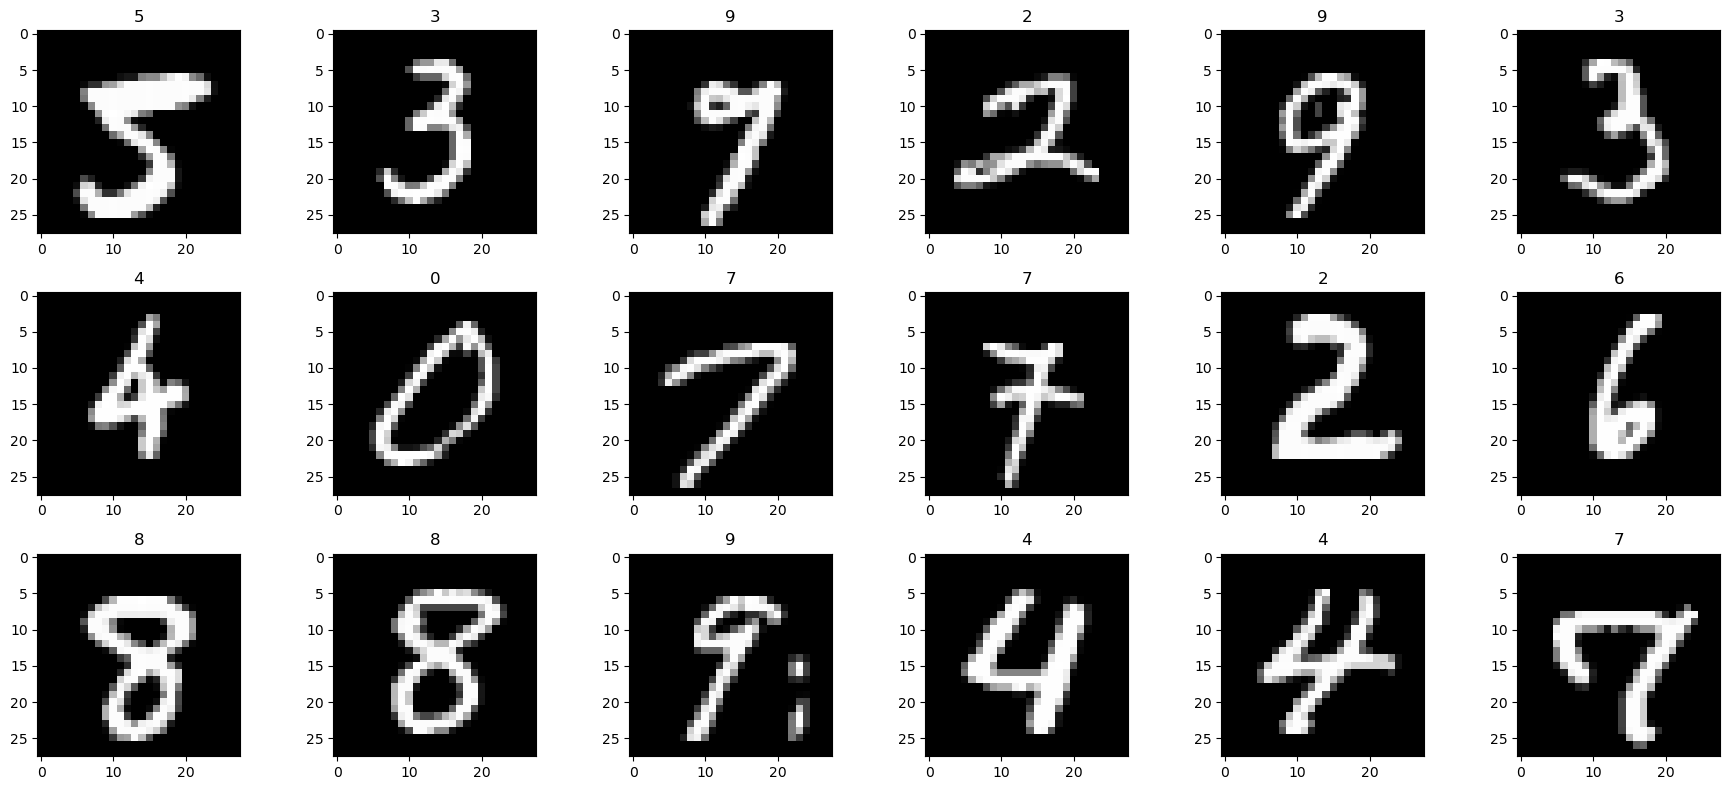

In [5]:
import matplotlib.pyplot as plt
def show_image(train_image, label, index):
    image_shaped = train_image.values.reshape(28,28)
    plt.subplot(3, 6, index+1)
    plt.imshow(image_shaped, cmap=plt.cm.gray)
    plt.title(label)


plt.figure(figsize=(18, 8))
sample_image = train_data.sample(18).reset_index(drop=True)
for index, row in sample_image.iterrows():
    label = row['label']
    image_pixels = row.drop('label')
    show_image(image_pixels, label, index)
plt.tight_layout()

## Data preprocessing

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

In [14]:
# Convert images into float vectors
X = train_data.drop(labels='label', axis=1).values.astype(np.float64)
y = train_data['label'].values.astype(np.int64)

X_test_submission = test_data.values.astype(np.float64)
# MNIST normalization constants
MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081
RND = 42

if 'label' not in train_data.columns:
    raise ValueError("train_data must include 'label' column")

X_train, X_temp, y_train, y_temp = train_test_split(
    X,y, test_size=0.2, random_state=RND, stratify=y
)

X_val, X_test_from_train, y_val, y_test_from_train = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RND, stratify=y_temp
)

print(f"Sizes -> train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test_from_train)}")

Sizes -> train: 33600, val: 4200, test: 4200


In [12]:
print(X_train[1])

[  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.  60. 141. 141. 216. 253. 253. 255.
 178. 141.  41.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.  63. 234. 252. 253. 240. 215. 252. 253.
 252. 252. 252. 101.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.  23. 234. 224. 168.  56.  43.  19.  56.  56.
  56. 171. 252. 235.  28.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0. 

## Build the MNISTFLat Dataset

In [15]:
class MNISTFlatDataset(Dataset):
    def __init__(self, X, y=None, transform=None, normalize=True):
        self.X = X
        self.y = y if y is None else np.asarray(y, dtype=np.int64)
        self.transform = transform
        self.normalize = normalize
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        img = self.X[idx]
        
        if self.normalize:
            img = img / 255.0
            
        if self.transform:
            img = self.transform(img)
            
        if self.normalize:
            img = (img - MNIST_MEAN) / MNIST_STD
            
        img_tensor = torch.from_numpy(img).float()
        if self.y is None:
            return img_tensor
        label = int(self.y[idx])
        return img_tensor, label
        

### DataLoaders

In [17]:
train_ds = MNISTFlatDataset(X_train, y_train, transform=None, normalize=None)
test_ds = MNISTFlatDataset(X_test_from_train, y_test_from_train, transform=None, normalize=None)
val_ds = MNISTFlatDataset(X_val, y_val, transform=None, normalize=None)

batch_size = 128
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [18]:
batch = next(iter(train_loader))
images, labels = batch
print("Batch images shape:", images.shape)  # expected (batch_size, 784) (last batch may be smaller)
print("Batch labels shape:", labels.shape)
print("Pixel stats (first batch): mean {:.4f}, std {:.4f}".format(images.mean().item(), images.std().item()))

Batch images shape: torch.Size([128, 784])
Batch labels shape: torch.Size([128])
Pixel stats (first batch): mean 32.5417, std 77.9817


## Build the Neural Network model (MLP)

### parameters

In [62]:
import math

input_dim = 28*28
n_layers = 6
hidden_dim = 512
num_classes = 10
dropout = 0.5
activation = "gelu"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_activation(name="gelu"):
    name = name.lower()
    if name == "relu":
        return nn.ReLU(inplace=True)
    if name == "gelu":
        return nn.GELU()
    if name == "swish":
        try:
            return nn.SiLU()  # SiLU ~ swish
        except:
            return nn.GELU()
    return nn.GELU()

In [63]:
class MLPBlock(nn.Module):
    def __init__(self, in_features, out_features, activation="gelu", dropout=dropout, use_layernorm=True):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features)
        self.act = get_activation(activation)
        self.dropout = nn.Dropout(dropout) if dropout>0 else nn.Identity()
        self.use_ln = use_layernorm
        self.ln = nn.LayerNorm(out_features) if use_layernorm else nn.Identity()

    def forward(self, x):
        x = self.fc(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.ln(x)
        return x

# Full MLP with optional residual connections when dims match
class ResidualMLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=1024, n_layers=8, num_classes=10, dropout=dropout, activation="gelu", use_layernorm=True):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim) if input_dim != hidden_dim else nn.Identity()
        self.blocks = nn.ModuleList()
        for i in range(n_layers):
            self.blocks.append(MLPBlock(hidden_dim, hidden_dim, activation=activation, dropout=dropout, use_layernorm=use_layernorm))
        self.head = nn.Sequential(
            nn.LayerNorm(hidden_dim) if use_layernorm else nn.Identity(),
            nn.Linear(hidden_dim, num_classes)
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_proj(x)
        for blk in self.blocks:
            out = blk(x)
            if out.shape == x.shape:
                x = x + out
            else:
                x = out
        logits = self.head(x)
        return logits

In [64]:
model = ResidualMLP(input_dim=input_dim, hidden_dim=hidden_dim, n_layers=n_layers,
                    num_classes=num_classes, dropout=dropout, activation=activation, use_layernorm=True)
model = model.to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"Device: {device}")
print(f"Model params: {count_params(model):,} parameters")
batch_size = 16
dummy = torch.randn(batch_size, input_dim, device=device)
with torch.no_grad():
    out = model(dummy)
print("Dummy forward output shape:", out.shape)

Device: cuda
Model params: 1,990,154 parameters
Dummy forward output shape: torch.Size([16, 10])


## Setting up the training loop

In [72]:
import torch.optim as optim
warmup_epochs = 1
criterion = nn.CrossEntropyLoss()
learning_rate = 5e-4
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)

main_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

num_train_steps = len(train_loader)
warmup_steps = warmup_epochs * num_train_steps


warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=1e-6, total_iters=warmup_steps
)

# Gradient clipping threshold
grad_clip = 1.0

print("Training components ready:")
print(f" - Optimizer: {optimizer.__class__.__name__}")
print(f" - LR: {learning_rate}")
print(f" - Weight Decay: 1e-4")
print(f" - Scheduler: ReduceLROnPlateau")
print(f" - Gradient Clipping: {grad_clip}")


Training components ready:
 - Optimizer: AdamW
 - LR: 0.0005
 - Weight Decay: 1e-4
 - Scheduler: ReduceLROnPlateau
 - Gradient Clipping: 1.0


###*For training against validation set*

In [76]:
# ===== Training Loop =====
from tqdm import tqdm

# Config
num_epochs = 50
use_amp = True

scaler = torch.amp.GradScaler(device=device, enabled=use_amp)
models_dir = './models'
save_path = os.path.join(models_dir,"best_mlp_model.pth")
best_val_acc = 0.0
grad_clip = 1.0

# Record the training result for visualization
train_losses = []
val_losses = []
train_accs = []
val_accs = []
grad_norms = []

def compute_grad_norm(model):
    total_norm = 0.0
    count = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2).item()
            total_norm += param_norm**2
            count += 1
    if count == 0:
        return 0.0
    return (total_norm ** 0.5)

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    grad_norm_accum = 0.0
    steps = 0

    train_loop = tqdm(train_loader, desc=f"Epoch {epoch:02d} [Train]", leave=False)
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        with torch.amp.autocast(device_type='cuda',enabled=use_amp):
            logits = model(x)
            loss = criterion(logits, y)
            
        scaler.scale(loss).backward()
        # Unscale gradient
        if use_amp:
            scaler.unscale_(optimizer)

        # compute grad norm for this step (before clipping/step)
        step_grad_norm = compute_grad_norm(model)
        grad_norm_accum += step_grad_norm

        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer)
        scaler.update()
        
        # warmup steps
        if epoch <= warmup_epochs:
            warmup_scheduler.step()

        running_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        steps += 1

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    avg_grad_norm = grad_norm_accum / max(1, steps)

    # Validation
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            val_running_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    epoch_val_loss = val_running_loss / val_total
    epoch_val_acc = val_correct / val_total

    # record metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    grad_norms.append(avg_grad_norm)

    if epoch > warmup_epochs:
        main_scheduler.step(epoch_val_acc)

    # Model checkpointing
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        if not os.path.exists(models_dir):
            os.makedirs(models_dir)
        torch.save(model.state_dict(), save_path)
        
    print(f"Epoch {epoch:02d} | train loss {epoch_train_loss:.4f} acc {epoch_train_acc*100:.2f}%"
          f" | val loss {epoch_val_loss:.4f} acc {epoch_val_acc*100:.2f}% | grad_norm {avg_grad_norm:.4f}")

print("Training finished.")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")

Epoch 01 [Train]:   0%|          | 0/263 [00:00<?, ?it/s]

AssertionError: No inf checks were recorded for this optimizer.

## Visualize the training process

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def plot_learning_curves(train_losses, val_losses, train_accs=None, val_accs=None):
    epochs = np.arange(1, len(train_losses)+1)
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, train_losses, label='train loss')
    plt.plot(epochs, val_losses, label='val loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss curves')
    plt.legend()

    if train_accs is not None and val_accs is not None:
        plt.subplot(1,2,2)
        plt.plot(epochs, np.array(train_accs)*100, label='train acc')
        plt.plot(epochs, np.array(val_accs)*100, label='val acc')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Accuracy curves')
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_grad_and_weights(grad_norms, model):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(np.arange(1, len(grad_norms)+1), grad_norms, label='grad L2 norm')
    plt.xlabel('Epoch')
    plt.ylabel('Grad L2 norm')
    plt.title('Gradient norm per epoch')
    plt.legend()

    # weight histogram (flatten all weights)
    all_weights = np.concatenate([p.detach().cpu().numpy().ravel() for p in model.parameters() if p.requires_grad])
    plt.subplot(1,2,2)
    plt.hist(all_weights, bins=80)
    plt.title('Histogram of model weights')
    plt.xlabel('weight value')
    plt.ylabel('count')
    plt.tight_layout()
    plt.show()

def plot_confusion_and_perclass(all_labels, all_preds, class_names=None):
    # all_labels/preds are lists of numpy arrays collected during validation
    y_true = np.concatenate(all_labels)
    y_pred = np.concatenate(all_preds)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(6,6))
    disp.plot(ax=ax, xticks_rotation='vertical')
    plt.title('Confusion matrix (val set)')
    plt.show()

    per_class_acc = cm.diagonal() / (cm.sum(axis=1) + 1e-12)
    plt.figure(figsize=(8,4))
    plt.bar(np.arange(len(per_class_acc)), per_class_acc*100)
    plt.xlabel('Class')
    plt.ylabel('Accuracy (%)')
    plt.title('Per-class accuracy (val)')
    plt.xticks(np.arange(len(per_class_acc)))
    plt.show()

# Show some misclassified examples from validation set
def show_misclassified(val_loader, model, limit=12):
    model.eval()
    mis_x = []
    mis_y = []
    mis_p = []
    with torch.no_grad():
        for x, y in val_loader:
            x_cpu = x.cpu()
            logits = model(x.to(device))
            preds = logits.argmax(dim=1).cpu()
            for img, label, pred in zip(x_cpu, y, preds):
                if label.item() != pred.item():
                    mis_x.append(img)
                    mis_y.append(label.item())
                    mis_p.append(pred.item())
                if len(mis_x) >= limit:
                    break
            if len(mis_x) >= limit:
                break

    if len(mis_x) == 0:
        print("No misclassified examples found in val set (maybe val acc is 100%).")
        return

    plt.figure(figsize=(12, 6))
    for i in range(len(mis_x)):
        plt.subplot(3, 4, i+1)
        img = (mis_x[i] * MNIST_STD) + MNIST_MEAN
        img = img.view(28,28).numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"t:{mis_y[i]} p:{mis_p[i]}")
        plt.axis('off')
    plt.suptitle('Some misclassified examples (val)')
    plt.show()

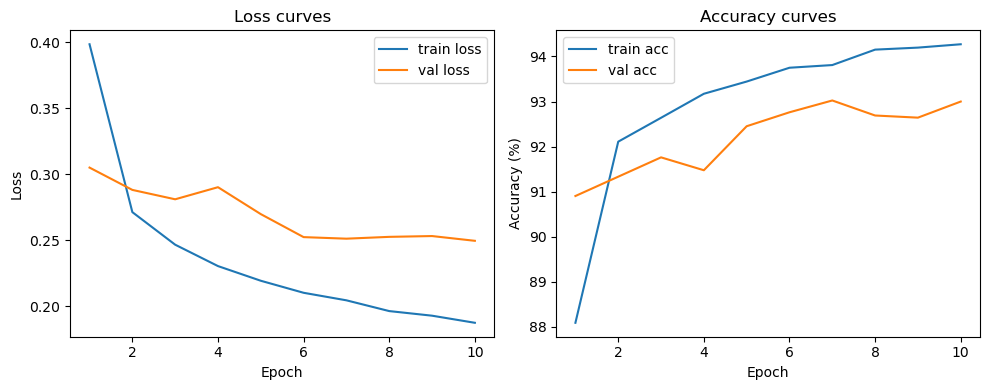

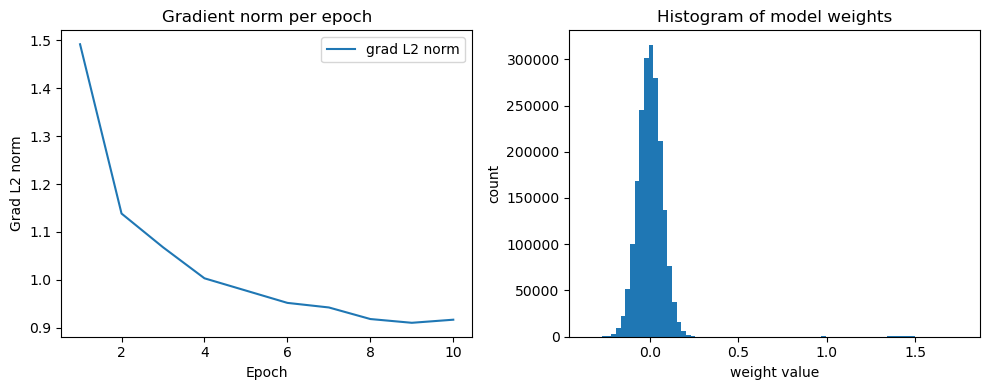

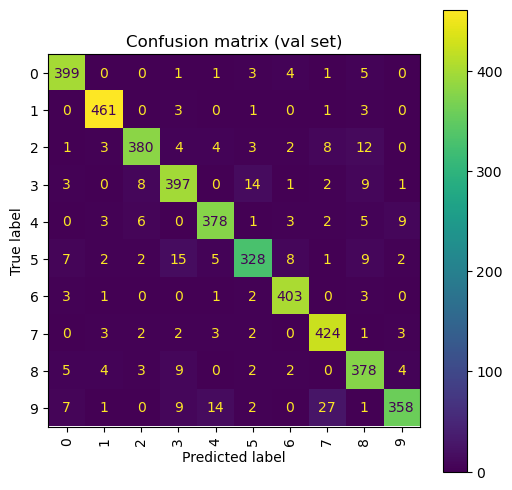

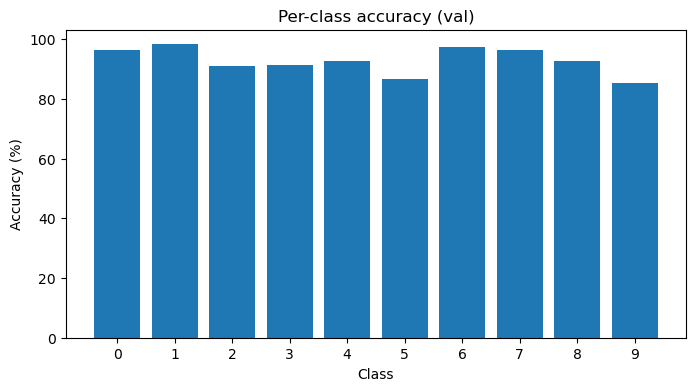

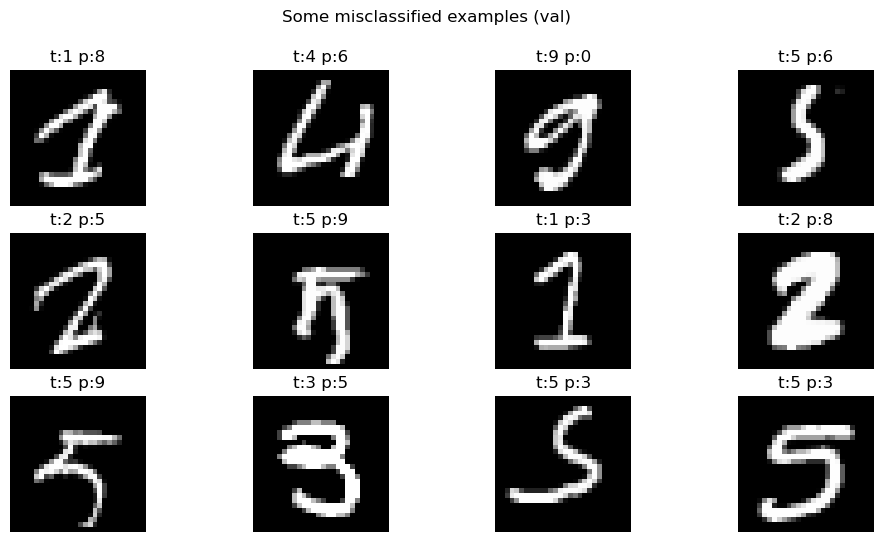

In [68]:
plot_learning_curves(train_losses, val_losses, train_accs, val_accs)
plot_grad_and_weights(grad_norms, model)
plot_confusion_and_perclass([np.concatenate(all_labels)], [np.concatenate(all_preds)])  # unwrap to expected shape
show_misclassified(val_loader, model, limit=12)

In [75]:
batch_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = True

# MNIST normalization constants (same as during training)
MNIST_MEAN = 0.1307
MNIST_STD  = 0.3081

test_df = pd.read_csv(test_path)
print("Test CSV shape:", test_df.shape)

class MNISTTestDataset(Dataset):
    def __init__(self, X, normalize=True):
        # X: numpy array shape (N,784) values 0..255 or already 0..1 floats
        self.X = X.astype(np.float32)
        self.normalize = normalize

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img_flat = self.X[idx].astype(np.float32) / 255.0  # scale to [0,1]
        tensor = torch.from_numpy(img_flat)  # shape (784,)
        if self.normalize:
            tensor = (tensor - MNIST_MEAN) / MNIST_STD
        return tensor

# prepare numpy array
if 'label' in test_df.columns:
    # unlikely for Kaggle test, but handle gracefully
    test_X = test_df.drop(columns=['label']).values
else:
    test_X = test_df.values

test_ds = MNISTTestDataset(test_X, normalize=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# --- Recreate model architecture exactly as training ---
# Paste the exact ResidualMLP class definition here or import it if in module.
# (Below assume ResidualMLP is defined in the notebook already.)
# Example: model = ResidualMLP(input_dim=784, hidden_dim=1024, n_layers=8, num_classes=10, dropout=0.3)
# If you restarted the kernel, make sure to re-run the model class code cell.

model = ResidualMLP(input_dim=28*28, hidden_dim=hidden_dim, n_layers=n_layers,
                    num_classes=10, dropout=dropout, activation=activation, use_layernorm=True)
model.load_state_dict(torch.load(save_path, map_location=device))
model.to(device)
model.eval()
print("Loaded model, param count:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# --- Inference loop ---
all_preds = []
with torch.no_grad():
    if use_amp:
        amp_ctx = torch.cuda.amp.autocast
    else:
        # dummy context manager
        from contextlib import nullcontext
        amp_ctx = nullcontext

    for batch in tqdm(test_loader, desc="Inference"):
        # batch: (B, 784)
        batch = batch.to(device)
        with amp_ctx():
            logits = model(batch)            # (B, 10)
            preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)

# concatenate
all_preds = np.concatenate(all_preds, axis=0)
assert len(all_preds) == len(test_ds), f"Prediction count {len(all_preds)} != test size {len(test_ds)}"

# --- Build submission DataFrame (Kaggle expects ImageId starting at 1) ---
submission_df = pd.DataFrame({
    "ImageId": np.arange(1, len(all_preds)+1),
    "Label": all_preds
})

submission_csv = "submission.csv"
submission_df.to_csv(submission_csv, index=False)
print(f"Saved submission file: {submission_csv} (rows: {len(submission_df)})")

# Quick peek
print(submission_df.head(10))

Test CSV shape: (28000, 784)
Loaded model, param count: 1990154


Inference:   0%|          | 0/110 [00:00<?, ?it/s]/tmp/ipykernel_3038/39022545.py:64: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp_ctx():
Inference: 100%|██████████| 110/110 [00:00<00:00, 175.52it/s]

Saved submission file: submission.csv (rows: 28000)
   ImageId  Label
0        1      7
1        2      0
2        3      7
3        4      7
4        5      7
5        6      4
6        7      7
7        8      4
8        9      4
9       10      4
